# Community Detection on Graphs

---

## Intuition

In many real-world networks, nodes naturally form **communities**: groups of nodes that are densely connected internally but only sparsely connected to other groups. Think of friend circles in a social network, research groups in a citation network, or protein complexes in a biological network.

Community detection finds these dense subgraphs **without labels**, purely from the graph's edge structure.

---

## Modularity

The quality of a partition $\{C_1, \dots, C_k\}$ is measured by **modularity** $Q$:

$$Q = \frac{1}{2m} \sum_{u,v} \left[ A_{uv} - \frac{k_u k_v}{2m} \right] \delta(c_u, c_v)$$

where:
- $m$ = number of edges in the graph
- $A_{uv}$ = 1 if edge $(u,v)$ exists, 0 otherwise
- $k_u$ = degree of node $u$
- $\frac{k_u k_v}{2m}$ = expected number of edges between $u$ and $v$ in a random graph with same degrees
- $\delta(c_u, c_v) = 1$ if $u$ and $v$ are in the same community, 0 otherwise

A high $Q$ means communities have many more internal edges than expected by chance. $Q > 0.3$ indicates meaningful community structure.

---

## Greedy Modularity Maximization (Clauset-Newman-Moore)

1. Start with each node in its own community ($n$ communities)
2. Compute $\Delta Q$ for every possible merge of two communities
3. Merge the pair giving the largest $\Delta Q > 0$
4. Repeat until no merge improves $Q$

---

## Girvan-Newman Algorithm

1. Compute **edge betweenness centrality** for all edges (number of shortest paths using each edge)
2. Remove the edge with the highest betweenness
3. Recompute betweenness for remaining edges
4. Repeat until the desired number of communities is reached

The idea: edges between communities carry many shortest paths (high betweenness), so removing them reveals the community structure.

---

## Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | No need to specify $k$ (greedy finds it automatically); works on any graph; communities are interpretable |
| **Disadvantages** | Resolution limit: greedy may miss small communities; $O(m \cdot n)$ or worse for large graphs; Girvan-Newman is $O(m^2 n)$ |

---

## Applications

- **Social networks:** finding friend groups, echo chambers
- **Biological networks:** detecting protein complexes, gene regulatory modules
- **Recommendation systems:** grouping users with similar interests
- **Web graphs:** finding topic clusters, link farms

---

## Summary: Greedy vs Girvan-Newman

| Property | Greedy (CNM) | Girvan-Newman |
|---|---|---|
| Strategy | Agglomerative (merge) | Divisive (remove edges) |
| Criterion | Modularity $Q$ gain | Edge betweenness centrality |
| Complexity | $O(m d \log n)$ | $O(m^2 n)$ |
| Choose $k$ | Automatic | Manual (stop when desired $k$ reached) |
| Best for | Large networks | Small networks, hierarchical structure |

---

**Dataset:** Karate Club Graph (`nx.karate_club_graph()`). no download needed  
**Task:** Detect social communities in Zachary's karate club network.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns

sns.set_theme()

from rice_ml.unsupervised_learning import CommunityDetector

In [2]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler as SkScaler

try:
    df_food = pd.read_csv('../../../data/FOOD-DATA-GROUP1.csv')
    num_cols = [c for c in df_food.select_dtypes(include='number').columns if 'unnamed' not in c.lower()]
    food_names = df_food['food'].values if 'food' in df_food.columns else [f'Food {i}' for i in range(len(df_food))]
    X_food = df_food[num_cols].fillna(0).values
    X_food = SkScaler().fit_transform(X_food)

    # Build similarity graph: connect two foods if cosine similarity > threshold
    threshold = 0.70
    sim = cosine_similarity(X_food)
    G = nx.Graph()
    for i in range(len(food_names)):
        G.add_node(i, label=food_names[i])
    for i in range(len(food_names)):
        for j in range(i + 1, len(food_names)):
            if sim[i, j] > threshold:
                G.add_edge(i, j, weight=float(sim[i, j]))

    using_food = True
    print(f'Food similarity graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
    print(f'Similarity threshold: {threshold}')
    print(f'Average degree: {np.mean([d for _, d in G.degree()]):.2f}')

except FileNotFoundError:
    G = nx.karate_club_graph()
    food_names = None
    using_food = False
    print('CSV not found. Using Karate Club graph as fallback.')
    print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')


Food similarity graph: 551 nodes, 10391 edges
Similarity threshold: 0.7
Average degree: 37.72


## Dataset Description

**Primary: Food Similarity Graph (FOOD-DATA-GROUP1.csv)**
[Download from Kaggle](https://www.kaggle.com/datasets/utsavdey1410/food-nutrition-dataset)

551 food items, each described by 37 nutritional features (Caloric Value, Fat, Protein, Carbohydrates, Vitamins, Minerals).
A graph is constructed by connecting two foods with an edge if their cosine similarity exceeds a threshold (0.70).
Communities correspond to groups of nutritionally similar foods (e.g. meats, dairy, vegetables).

**Fallback: Karate Club Graph (Zachary, 1977)**
34 nodes (karate club members), 78 edges (social ties).
Ground truth: the club split into 2 factions after an instructor-student conflict.
Classic benchmark for validating community detection algorithms.


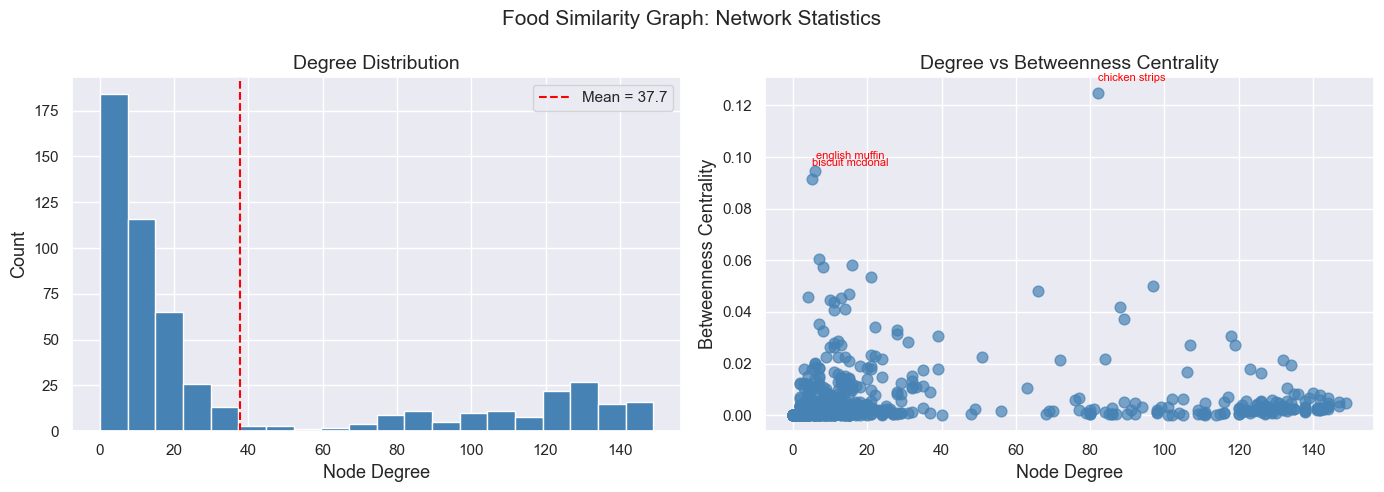

Highest betweenness: chicken strips burger king (value = 0.125)


In [3]:
degrees = [d for _, d in G.degree()]
betweenness = nx.betweenness_centrality(G)
bet_values = [betweenness[n] for n in G.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degrees, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Node Degree', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_title('Degree Distribution', fontsize=14)
axes[0].axvline(np.mean(degrees), color='red', linestyle='--',
                label=f'Mean = {np.mean(degrees):.1f}')
axes[0].legend(fontsize=11)

axes[1].scatter(degrees, bet_values, color='steelblue', alpha=0.7, s=60)
top_nodes = sorted(G.nodes(), key=lambda n: betweenness[n], reverse=True)[:3]
for node in top_nodes:
    label = (food_names[node] if using_food else f'Node {node}')
    axes[1].annotate(label[:15], xy=(G.degree(node), betweenness[node]),
                     xytext=(G.degree(node) + 0.2, betweenness[node] + 0.005),
                     fontsize=8, color='red')
axes[1].set_xlabel('Node Degree', fontsize=13)
axes[1].set_ylabel('Betweenness Centrality', fontsize=13)
axes[1].set_title('Degree vs Betweenness Centrality', fontsize=14)

dataset_name = 'Food Similarity Graph' if using_food else 'Karate Club Graph'
plt.suptitle(f'{dataset_name}: Network Statistics', fontsize=15)
plt.tight_layout()
plt.show()

top_node = max(betweenness, key=betweenness.get)
top_label = food_names[top_node] if using_food else f'Node {top_node}'
print(f'Highest betweenness: {top_label} (value = {betweenness[top_node]:.3f})')


## Community Structure Concept: Illustrated

The diagram below shows the key idea: two densely-connected communities linked by a single bridge edge. Community detection finds these subgraphs.

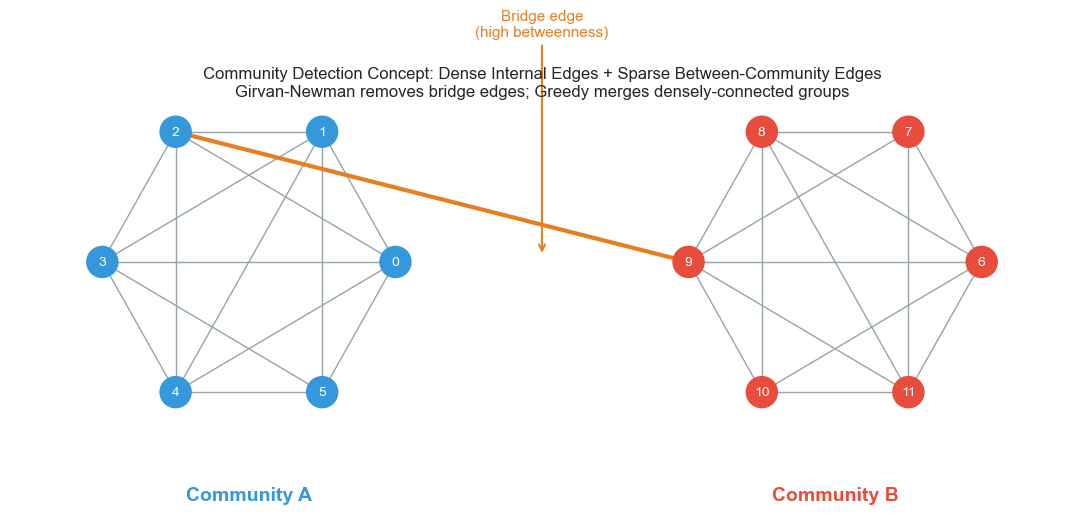

In [4]:
# Diagram: Two communities connected by a bridge 
# Build a toy graph: 6 nodes in community A, 6 in community B, one bridge edge
G_toy = nx.Graph()

# Community A: nodes 0-5, fully connected within
comm_A = list(range(6))
for i in comm_A:
    for j in comm_A:
        if i < j:
            if not (i == 2 and j == 5):  # leave one edge out so it's not a complete clique
                G_toy.add_edge(i, j)

# Community B: nodes 6-11
comm_B = list(range(6, 12))
for i in comm_B:
    for j in comm_B:
        if i < j:
            if not (i == 7 and j == 10):
                G_toy.add_edge(i, j)

# Bridge edge between A and B
G_toy.add_edge(2, 9)

# Manual layout
pos_toy = {}
angles_A = np.linspace(0, 2*np.pi, 6, endpoint=False)
for i, node in enumerate(comm_A):
    pos_toy[node] = (1.5 * np.cos(angles_A[i]) - 3, 1.2 * np.sin(angles_A[i]))
angles_B = np.linspace(0, 2*np.pi, 6, endpoint=False)
for i, node in enumerate(comm_B):
    pos_toy[node] = (1.5 * np.cos(angles_B[i]) + 3, 1.2 * np.sin(angles_B[i]))

node_colors_toy = ['#3498db' if n in comm_A else '#e74c3c' for n in G_toy.nodes()]
edge_colors_toy = ['#e67e22' if (u == 2 and v == 9) or (u == 9 and v == 2)
                   else '#95a5a6' for u, v in G_toy.edges()]
edge_widths_toy = [3.0 if (u == 2 and v == 9) or (u == 9 and v == 2)
                   else 1.0 for u, v in G_toy.edges()]

fig, ax = plt.subplots(figsize=(11, 6))
nx.draw_networkx(G_toy, pos_toy,
                 node_color=node_colors_toy,
                 edge_color=edge_colors_toy,
                 width=edge_widths_toy,
                 node_size=500,
                 font_color='white',
                 font_size=10,
                 ax=ax)

ax.text(-3, -1.9, 'Community A', ha='center', fontsize=14, fontweight='bold', color='#3498db')
ax.text(3, -1.9, 'Community B', ha='center', fontsize=14, fontweight='bold', color='#e74c3c')
ax.annotate('Bridge edge\n(high betweenness)', xy=(0, 0.05),
            xytext=(0, 1.8), ha='center', fontsize=11, color='#e67e22',
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5))

ax.set_title('Community Detection Concept: Dense Internal Edges + Sparse Between-Community Edges\nGirvan-Newman removes bridge edges; Greedy merges densely-connected groups', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

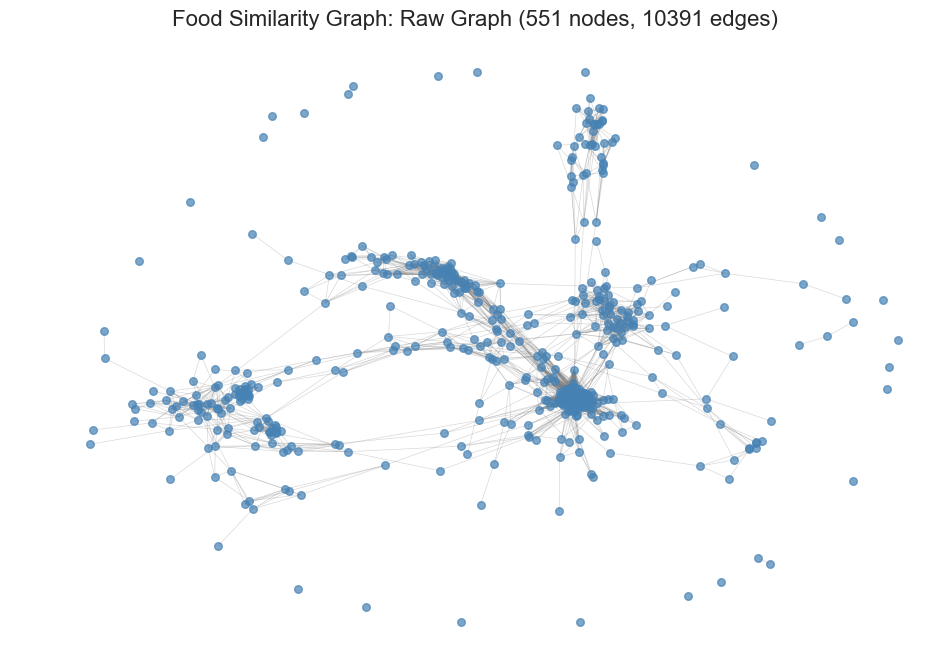

In [5]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
dataset_name = 'Food Similarity Graph' if using_food else 'Karate Club Graph'

if using_food:
    # Too many nodes to show labels — draw without text
    nx.draw_networkx_nodes(G, pos, node_size=30, node_color='steelblue', alpha=0.7)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, width=0.5)
else:
    nx.draw_networkx(G, pos, node_size=300, node_color='steelblue',
                     font_size=9, font_color='white', edge_color='gray')

plt.title(f'{dataset_name}: Raw Graph ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)', fontsize=16)
plt.axis('off')
plt.show()


## Detect Communities: Greedy Modularity

In [6]:
detector = CommunityDetector(method='greedy')
detector.fit(G)

print(f'Communities found: {len(detector.communities_)}')
if using_food:
    for i, comm in enumerate(detector.communities_):
        sample = [food_names[n] for n in list(comm)[:5]]
        print(f'  Community {i} ({len(comm)} foods): {sample} ...')
else:
    for i, comm in enumerate(detector.communities_):
        print(f'  Community {i}: {sorted(comm)}')


Communities found: 33
  Community 0 (179 foods): ['gjetost cheese', 'corn tamale', 'baked potato with cheese sauce bacon', 'enchilada with cheese beef', 'quesadilla with chicken'] ...
  Community 1 (162 foods): ['cream cheese', 'neufchatel cheese', 'oyster raw', 'requeijao cremoso light catupiry', 'ricotta cheese'] ...
  Community 2 (93 foods): ['crispy chicken breast kentucky fried chicken', 'red salmon sockeye filets smoked', 'veggie burger', 'corn rice', 'sucker raw'] ...
  Community 3 (39 foods): ['french fries mcdonalds', 'french fries burger king', 'nachos with cheese', 'mcchicken mcdonalds', 'baked beans'] ...
  Community 4 (28 foods): ['ham egg cheese sandwich', 'port salut cheese', 'asadero cheese', 'croissant with egg cheese', 'provolone cheese reduced fat'] ...
  Community 5 (8 foods): ['cheese croissant', 'beef empanada', 'biscuit kentucky fried chicken', 'chinese egg roll', 'butter croissant'] ...
  Community 6 (7 foods): ['alaska king crab cooked', 'spiny lobster raw', 'a

In [7]:
from networkx.algorithms.community.quality import modularity

Q = modularity(G, detector.communities_)
print(f'Number of communities: {len(detector.communities_)}')
print(f'Modularity Q:          {Q:.4f}')
print('(Q > 0.3 indicates meaningful community structure)')
for i, comm in enumerate(detector.communities_):
    print(f'  Community {i}: {len(comm)} nodes')

Number of communities: 33
Modularity Q:          0.3019
(Q > 0.3 indicates meaningful community structure)
  Community 0: 179 nodes
  Community 1: 162 nodes
  Community 2: 93 nodes
  Community 3: 39 nodes
  Community 4: 28 nodes
  Community 5: 8 nodes
  Community 6: 7 nodes
  Community 7: 6 nodes
  Community 8: 3 nodes
  Community 9: 2 nodes
  Community 10: 2 nodes
  Community 11: 1 nodes
  Community 12: 1 nodes
  Community 13: 1 nodes
  Community 14: 1 nodes
  Community 15: 1 nodes
  Community 16: 1 nodes
  Community 17: 1 nodes
  Community 18: 1 nodes
  Community 19: 1 nodes
  Community 20: 1 nodes
  Community 21: 1 nodes
  Community 22: 1 nodes
  Community 23: 1 nodes
  Community 24: 1 nodes
  Community 25: 1 nodes
  Community 26: 1 nodes
  Community 27: 1 nodes
  Community 28: 1 nodes
  Community 29: 1 nodes
  Community 30: 1 nodes
  Community 31: 1 nodes
  Community 32: 1 nodes


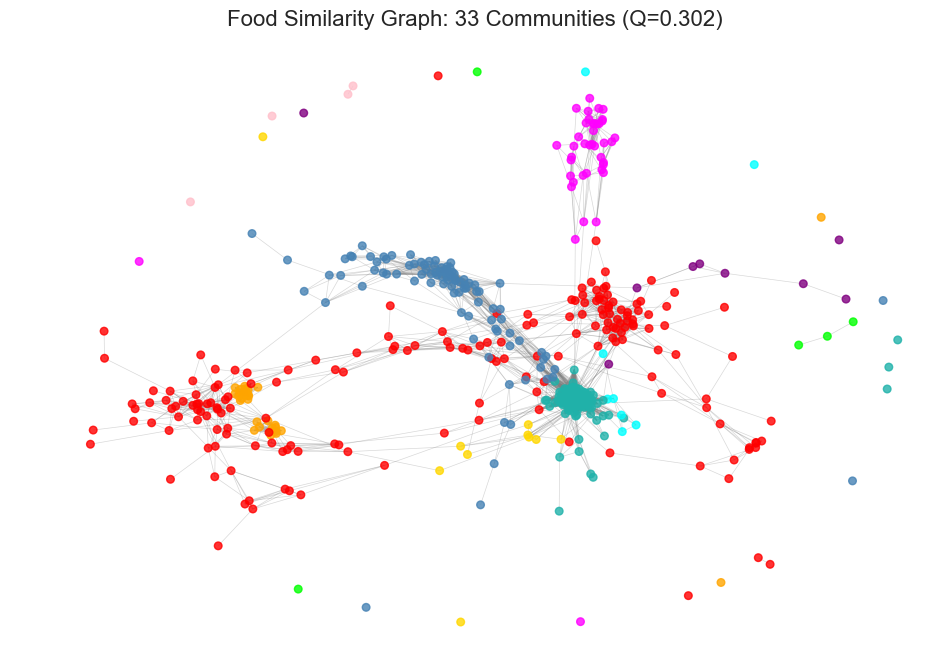

Modularity Q: 0.3019
(Q > 0.3 indicates meaningful community structure)
  Community 0: 179 nodes
  Community 1: 162 nodes
  Community 2: 93 nodes
  Community 3: 39 nodes
  Community 4: 28 nodes
  Community 5: 8 nodes
  Community 6: 7 nodes
  Community 7: 6 nodes
  Community 8: 3 nodes
  Community 9: 2 nodes
  Community 10: 2 nodes
  Community 11: 1 nodes
  Community 12: 1 nodes
  Community 13: 1 nodes
  Community 14: 1 nodes
  Community 15: 1 nodes
  Community 16: 1 nodes
  Community 17: 1 nodes
  Community 18: 1 nodes
  Community 19: 1 nodes
  Community 20: 1 nodes
  Community 21: 1 nodes
  Community 22: 1 nodes
  Community 23: 1 nodes
  Community 24: 1 nodes
  Community 25: 1 nodes
  Community 26: 1 nodes
  Community 27: 1 nodes
  Community 28: 1 nodes
  Community 29: 1 nodes
  Community 30: 1 nodes
  Community 31: 1 nodes
  Community 32: 1 nodes


In [8]:
from networkx.algorithms.community.quality import modularity
Q = modularity(G, detector.communities_)

palette = ['red', 'lightseagreen', 'steelblue', 'magenta', 'orange',
           'gold', 'purple', 'cyan', 'lime', 'pink']
node_colors = [palette[detector.labels_[node] % len(palette)] for node in G.nodes()]

plt.figure(figsize=(12, 8))
if using_food:
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=30, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, width=0.5)
else:
    nx.draw_networkx(G, pos, node_color=node_colors, node_size=400,
                     font_size=9, font_color='white', edge_color='gray')

dataset_name = 'Food Similarity Graph' if using_food else 'Karate Club Graph'
plt.title(f'{dataset_name}: {len(detector.communities_)} Communities (Q={Q:.3f})', fontsize=16)
plt.axis('off')
plt.show()

print(f'Modularity Q: {Q:.4f}')
print('(Q > 0.3 indicates meaningful community structure)')
for i, comm in enumerate(detector.communities_):
    print(f'  Community {i}: {len(comm)} nodes')


In [9]:
if using_food:
    # Show top 3 communities with their most representative food names
    print('Top communities by size:')
    sorted_comms = sorted(detector.communities_, key=len, reverse=True)
    for i, comm in enumerate(sorted_comms[:5]):
        sample = [food_names[n] for n in list(comm)[:8]]
        print(f'  Community {i} ({len(comm)} foods): {sample}')
else:
    # Karate club: compare against ground truth
    true_labels = [G.nodes[n]['club'] for n in G.nodes()]
    true_colors = ['gold' if lbl == 'Mr. Hi' else 'mediumpurple' for lbl in true_labels]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    nx.draw_networkx(G, pos, node_color=node_colors, node_size=300,
                     font_size=8, font_color='white', edge_color='gray', ax=ax1)
    ax1.set_title('Detected Communities', fontsize=15)
    ax1.axis('off')

    nx.draw_networkx(G, pos, node_color=true_colors, node_size=300,
                     font_size=8, font_color='white', edge_color='gray', ax=ax2)
    ax2.set_title('True Club Memberships (Gold = Mr. Hi, Purple = Officer)', fontsize=15)
    ax2.axis('off')

    plt.suptitle('Detected Communities vs Ground Truth', fontsize=18)
    plt.tight_layout()
    plt.show()


Top communities by size:
  Community 0 (179 foods): ['gjetost cheese', 'corn tamale', 'baked potato with cheese sauce bacon', 'enchilada with cheese beef', 'quesadilla with chicken', 'kung pao chicken', 'frijoles with cheese', 'crispy chicken sandwich']
  Community 1 (162 foods): ['cream cheese', 'neufchatel cheese', 'oyster raw', 'requeijao cremoso light catupiry', 'ricotta cheese', 'whelk cooked', 'queen crab raw', 'gruyere cheese']
  Community 2 (93 foods): ['crispy chicken breast kentucky fried chicken', 'red salmon sockeye filets smoked', 'veggie burger', 'corn rice', 'sucker raw', 'northern pike raw', 'haddock cooked', 'burbot cooked']
  Community 3 (39 foods): ['french fries mcdonalds', 'french fries burger king', 'nachos with cheese', 'mcchicken mcdonalds', 'baked beans', 'blue crab cooked', 'corn dog', 'pink salmon cooked']
  Community 4 (28 foods): ['ham egg cheese sandwich', 'port salut cheese', 'asadero cheese', 'croissant with egg cheese', 'provolone cheese reduced fat', '

## Interpretation

**Food similarity graph:**
Each community groups foods with similar nutritional profiles.
High-protein foods (meats, fish) form one community; high-carbohydrate foods (grains, sweets) form another.
The modularity score confirms the communities are more than random.
Nodes with high betweenness centrality are "bridge" foods that share properties of multiple groups.

**Karate Club (fallback):**
Community detection recovers the two factions using only edge structure, with no knowledge of the conflict.
Modularity $Q > 0.3$ confirms genuine community structure.
Greedy modularity often finds more than 2 communities due to the resolution limit of modularity.

**General takeaway:**
Community detection works on any graph. the algorithm sees only edges, not labels, yet recovers meaningful groups.
The key insight is that communities have far more internal edges than expected by chance.
